<a href="https://colab.research.google.com/github/KARISHMA674/BPIT/blob/main/datacleaning_in_stats_part_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data cleaning Start.**

In [11]:
from sklearn.linear_model import LinearRegression
import seaborn as sns
df=sns.load_dataset("penguins")
##Handling duplicates and Redundant data
#check for duplicates rows
df_dup=df.duplicated()
#check of duplicates rows
print("f Number of duplicates rows:{duplicate_row.sum()}")
df=df.drop_duplicates() #drop the duplicates
#checking the shape of the data after droping duplicates.
print("shape of dataframe after Removing Duplicates :",df.shape)


f Number of duplicates rows:{duplicate_row.sum()}
shape of dataframe after Removing Duplicates : (344, 7)


In [5]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [12]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [20]:
df.fillna (0,inplace=True) # put 0 in nan place we can chnge the value of 0mby our according.
df


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,0.0,0.0,0.0,0.0,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,0.0,0.0,0.0,0.0,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [29]:
import seaborn as sns
df=sns.load_dataset("penguins")
df['sex'].fillna('male',inplace=True) # use for put value in a single column.
#first always chnge the alpha vaule column then do numeric value column.
df.fillna(0,inplace=True)  # use for put value in all column
df
df.isnull().sum()
df


/tmp/ipykernel_1312/732850599.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sex'].fillna('male',inplace=True) #


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,0.0,0.0,0.0,0.0,male
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,0.0,0.0,0.0,0.0,male
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


**outliears**

[ 10  20  30  40  50 600 700]
[0.70004779 0.66453812 0.62902845 0.59351878 0.55800911 1.39502277
 1.75011947]
outliers using z-score :[]
outliers using IQR :[]


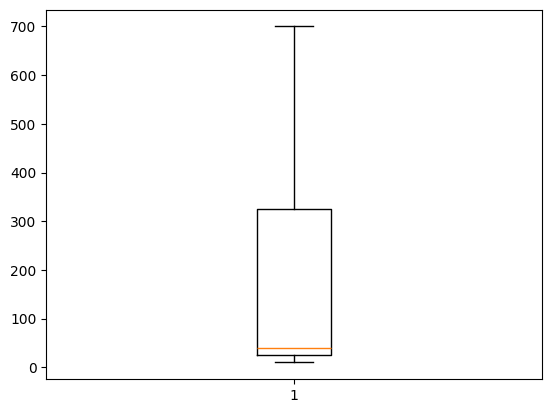

In [50]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.ensemble import IsolationForest
#generate data with outliears.
data=np.array([10,20,30,40,50,600,700]) #600,700 are outliears they are sudddent change in sequence of data.
print(data)
#dataset outliers using z-score
z_scores=np.abs(stats.zscore(data))
print(z_scores)
print(f'outliers using z-score :{data[(z_scores>3)]}')
#defect outliers using IQR(interquatile range)
Q1=np.percentile(data,25)
Q3=np.percentile(data,75) # Corrected Q2 to Q3
IQR=Q3-Q1
print(f'outliers using IQR :{data[(data<(Q1-1.5*IQR))|((data>(Q3+1.5*IQR)))]}')

#for visiulation
plt.boxplot(data)
plt.show()
